### Gradient Boosted Decision Trees

In [74]:
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt


In [68]:
df = pd.read_table("Lab Files\\resources\\course3\\assets\\fruit_data_with_colors.txt")
df.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [69]:
df.isna().sum()

fruit_label      0
fruit_name       0
fruit_subtype    0
mass             0
width            0
height           0
color_score      0
dtype: int64

In [70]:
X = df[df.columns[3:6]] # mass, width, height
y = df[df.columns[0]] # fruit_label

# using make classification
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [71]:
X_train.shape, y_train.shape

((750, 20), (750,))

In [72]:
rf = GradientBoostingClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_scores = rf.predict_proba(X_test)[:,1]

In [73]:
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)
roc_auc, accuracy_score(y_test, y_pred)

(np.float64(0.9391304347826086), 0.884)

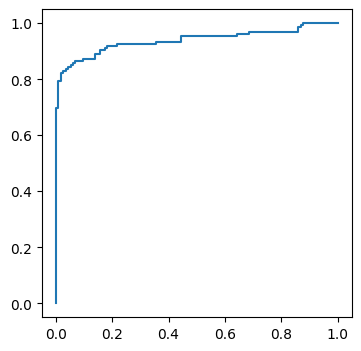

In [76]:
plt.figure(figsize=(4,4))
plt.plot(fpr, tpr)
plt.show()